In [1]:
import pandas as pd, matplotlib, matplotlib.pyplot as plt
import matplotlib_venn, upsetplot
from af2genomics import *

In [2]:
df_source = read_summary_source(summary=True)[['summary_source']]
df_ppi = read_ppi_reselect().merge(df_source, left_on='interaction_id', right_index=True).query('pdockq > .23')
df_ppi['summary_source'] = df_ppi['summary_source'].str.split(':')
df_ppi

1,302,716 raw records
1,302,593 after discarding non-dimers
909,264 after keeping uniprot_id-s in AF2 single fragment structures
499,321 unique interaction_id-s
310,581 raw records
310,572 after discarding non-dimers
211,081 after keeping uniprot_id-s in AF2 single fragment structures
211,079 after naive de-duplication of interaction_id
106,153 with pdockq > .23
24,524 with pdockq > .5


,interaction_id,pair,afparams,interface_plddt,pdockq,pdockq_fd,pdockq2,clashes,protein1,chain1,residues1,protein2,chain2,residues2,uniprot_id_A,uniprot_id_B,pdb,summary_source
0,P62328_P63313,P62328_P63313,multimer1,61.0,0.25,0.255,NaN,2,P62328,A,"6,10,13,14,17,20,21,24,29,31,35,38,39,42,43,44",P63313,B,"9,12,13,16,17,19,20,23,24,27,29,31,33,34,35,36...",P62328,P63313,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[string, xlinkdb]"
2,P62273_P62273,P62273_P62273,multimer1_rec20,87.0,0.47,0.414,0.45,0,P62273,A,"1,3,6,7,8,9,10,17,22,23,24,25,26,27,35,36,46,4...",P62273,B,"1,3,6,7,8,9,10,17,22,23,24,25,26,27,28,35,36,4...",P62273,P62273,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,[hip]
9,P02795_P04732,P02795_P04732,multimer1_rec10,79.0,0.32,0.324,0.34,0,P02795,A,"21,22,23,24,25,26,27,29,30,31,32,33,39,40,42,4...",P04732,B,"2,21,22,23,24,25,26,27,29,30,31,32,33,39,40,42...",P02795,P04732,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[otar, string]"
10,P02795_P80294,P02795_P80294,multimer1_rec10,80.0,0.34,0.341,0.36,0,P02795,A,"21,22,23,24,25,26,27,29,30,31,32,33,39,40,42,4...",P80294,B,"2,21,22,23,24,25,26,27,29,30,31,32,33,39,40,42...",P02795,P80294,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[otar, string]"
11,P02795_P80297,P02795_P80297,multimer1_rec10,77.0,0.30,0.308,0.27,0,P02795,A,"2,21,22,23,24,25,26,27,29,30,31,32,33,39,40,42...",P80297,B,"2,21,22,23,24,25,26,27,29,30,31,32,33,39,40,42...",P02795,P80297,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[otar, string]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211073,Q5T200_Q69YN4,Q5T200_Q69YN4,multimer1,60.0,0.50,0.509,0.00,0,Q5T200,A,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,3...",Q69YN4,B,"2,3,4,5,6,7,8,9,10,12,13,29,31,32,33,34,35,36,...",Q5T200,Q69YN4,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[corum, intact, otar, string]"
211075,Q86YZ3_Q9NUX5,Q86YZ3_Q9NUX5,multimer1,62.0,0.32,0.324,0.00,0,Q86YZ3,A,"372,373,374,375,376,377,378,379,380,381,382,38...",Q9NUX5,B,"18,150,151,152,153,154,155,156,157,158,162,163...",Q86YZ3,Q9NUX5,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[BioGRID, bioplex]"
211076,Q01082_Q6IQ23,Q01082_Q6IQ23,multimer1,65.0,0.39,0.388,0.00,0,Q01082,A,"102,105,107,163,164,165,166,167,168,169,171,17...",Q6IQ23,B,"506,507,508,509,510,511,512,513,514,515,516,51...",Q01082,Q6IQ23,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[intact, otar]"
211077,Q07864_Q9UNS1,Q07864_Q9UNS1,multimer1,81.0,0.67,0.655,0.00,0,Q07864,A,"272,273,274,275,276,277,278,288,289,293,296,29...",Q9UNS1,B,"1185,1187,1188,1189,1190,1191,1192,1193,1194,1...",Q07864,Q9UNS1,/cluster/work/beltrao/jjaenes/23.12.06_ppi_res...,"[BioGRID, otar, string]"


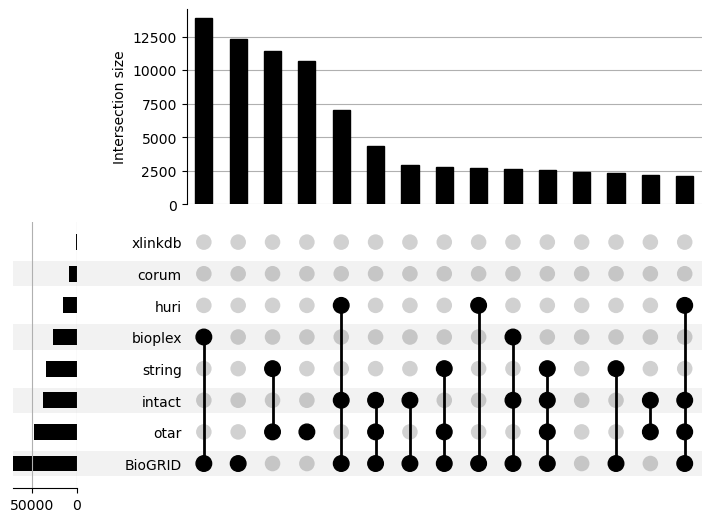

In [3]:
sources_drop_ = ['', 'gstaiger', 'benchmark', 'Isoform', 'humap', 'negatome', 'hip', 'asd', 'arne_bench', 'gtex']
data_ = upsetplot.from_memberships(df_ppi['summary_source']).droplevel(sources_drop_, axis=0)
upsetplot.UpSet(data_, subset_size='count', sort_by='cardinality', min_subset_size=2000)#, title='Previous evidence for PPI models with pDockQ > 0.23')

In [4]:
df_sources_ = df_ppi.explode('summary_source')['summary_source'].value_counts()
df_sources_ = df_sources_.loc[ ~df_sources_.index.isin(sources_drop_ + ['otar', 'xlinkdb', 'bioplex', 'intact', 'corum', 'huri']) ]
df_sources_

BioGRID    71572
string     34440
Name: summary_source, dtype: int64

In [5]:
def summary_source_top_(l_):
    l___ = [l__ for l__ in l_ if l__ in df_sources_.index]
    #print(l_)
    #print(l___)
    try:
        return df_sources_.loc[ l___ ].head(1).index.tolist()[0]
    except:
        return 'other'

df_ppi['summary_source_top'] = df_ppi['summary_source'].map(summary_source_top_)

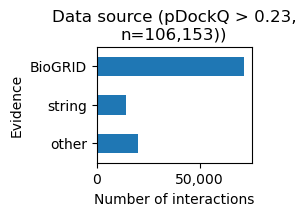

In [10]:
df_ppi['summary_source_top'].value_counts().to_frame().loc[['BioGRID', 'string', 'other']].plot.barh(legend=None, figsize=(2, 1.5))
plt.gca().set_title(f'Data source (pDockQ > 0.23,\nn={uf(len(df_ppi))}))')
plt.gca().set_xlabel('Number of interactions')
plt.gca().set_ylabel('Evidence')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.savefig('interaction_evidence.svg', bbox_inches='tight', transparent=True)